# Hough Circles (structured version)

Same logic as your original notebook, reorganized for readability.

⚠️ param1 is computed dynamically (NOT taken from preset).


In [497]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [498]:
# -----------------------------
# Configuration
# -----------------------------

path = "data/images/gp6/64.jpg"
#path = "data/images/gp2/3.jpeg"

TARGET_W, TARGET_H = 640, 480

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

GAUSS_KSIZE = 5
GAUSS_SIGMA = 2

# Presets: param1 REMOVED on purpose (param1 is dynamic)
HOUGH_PRESETS = {
    "red_coins_image": {
        "dp": 1.4,
        "minDist": 40,
        "param2": 70,
    },
    "gray_bg_image": {
        "dp": 1.4,
        "minDist": 40,
        "param2": 65,
    },
    "exp":{
        "dp": 1.15, #1.1 works for gray but 1.2 for red idk why so 1.15 is good
        "minDist": 30,
        "param2": 60,
    }
}

ACTIVE_HOUGH_PRESET = "exp"#"red_coins_image"

CIRCLE_OUTLINE_COLOR = (0, 255, 0)
CIRCLE_OUTLINE_THICKNESS = 2
CENTER_COLOR = (255, 0, 0)
CENTER_RADIUS = 2
CENTER_THICKNESS = 3

FIGSIZE = (8, 8)


In [499]:
# -----------------------------
# Helpers
# -----------------------------

def resolve_image_path(relative_path: str) -> Path:
    p = Path(relative_path)
    if not p.exists():
        p = Path("../" + relative_path)
    return p


def read_bgr_or_raise(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image at {image_path.resolve()}")
    return image_bgr


def letterbox_resize_to_canvas(image_bgr: np.ndarray, target_w: int, target_h: int) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))

    resized = cv2.resize(
        image_bgr,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR,
    )

    canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def show_image(img, title: str, cmap=None) -> None:
    plt.figure(figsize=FIGSIZE)
    if cmap is None:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def apply_clahe_on_l_channel(image_bgr: np.ndarray,
                             clip_limit: float,
                             tile_grid_size: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_clahe = clahe.apply(l_channel)

    clahe_bgr = cv2.cvtColor(cv2.merge((l_clahe, a_channel, b_channel)), cv2.COLOR_LAB2BGR)
    clahe_rgb = cv2.cvtColor(clahe_bgr, cv2.COLOR_BGR2RGB)
    return clahe_bgr, clahe_rgb


def auto_hough_param1_from_gradient(gray_u8: np.ndarray,
                                    blur_ksize: int = 5,
                                    perc: float = 90.0,
                                    scale: float = 1.0,
                                    clamp=(20, 250)):
    """Pick Hough param1 (upper Canny threshold) from gradient magnitude."""
    if gray_u8.ndim != 2:
        raise ValueError("expected 2D grayscale")
    if gray_u8.dtype != np.uint8:
        gray_u8 = np.clip(gray_u8, 0, 255).astype(np.uint8)

    if blur_ksize and blur_ksize >= 3:
        if blur_ksize % 2 == 0:
            blur_ksize += 1
        g = cv2.GaussianBlur(gray_u8, (blur_ksize, blur_ksize), 0)
    else:
        g = gray_u8

    gx = cv2.Scharr(g, cv2.CV_32F, 1, 0)
    gy = cv2.Scharr(g, cv2.CV_32F, 0, 1)
    mag = cv2.magnitude(gx, gy)

    m = mag[mag > 1e-3]
    if m.size == 0:
        return 100

    t = np.percentile(m, perc) * scale
    return int(np.clip(t, clamp[0], clamp[1]))

def auto_minradius_plateau(
    blurred: np.ndarray,
    base_params: dict,
    minR_start: int = 10,
    minR_end: int = 120,
    step: int = 2,
    keep_top_k: int = 20,
):
    """
    Rule:
    1) Sweep minR.
    2) Keep only "good" results: nested_pairs==0 AND max_intrusions_in_one==0.
    3) Among good results, group by n (#circles).
    4) Pick the most FREQUENT n (mode of n). Tie-breaker: larger n wins.
       IMPORTANT: ignore n==0 if there exists any n>0.
    5) From minR values that produced that n, pick the MEDIAN minR.
    """
    results = []
    for minR in range(minR_start, minR_end + 1, step):
        params = base_params.copy()
        params["minRadius"] = int(minR)
        circles_int = run_hough_with_params(blurred, params)
        _, m = circle_nesting_score(circles_int)
        results.append((minR, m))

    ok = [(minR, m) for (minR, m) in results if (m["nested_pairs"] == 0 and m["max_intrusions_in_one"] == 0)]
    if len(ok) == 0:
        best_nested = min(m["nested_pairs"] for (_, m) in results)
        cand = [(minR, m) for (minR, m) in results if m["nested_pairs"] == best_nested]
        best_intr = min(m.get("max_intrusions_in_one", 0) for (_, m) in cand)
        cand = [(minR, m) for (minR, m) in cand if m.get("max_intrusions_in_one", 0) == best_intr]
        best_n = max(m["n"] for (_, m) in cand)
        mins = sorted([minR for (minR, m) in cand if m["n"] == best_n])
        chosen = mins[len(mins) // 2]
        return chosen, {"reason": "no_good_results", "best_nested": best_nested, "best_intr": best_intr, "best_n": best_n}, results

    # Group minR by n
    n_to_minR = {}
    for minR, m in ok:
        n = int(m["n"])
        n_to_minR.setdefault(n, []).append(int(minR))

    # ---- FIX: ignore n==0 if any n>0 exists ----
    n_to_minR_sel = {n: v for n, v in n_to_minR.items() if n > 0}
    if len(n_to_minR_sel) == 0:
        n_to_minR_sel = n_to_minR  # only zeros exist -> allow 0

    # Mode of n by frequency; tie-breaker: higher n
    counts = [(n, len(v)) for n, v in n_to_minR_sel.items()]
    max_freq = max(freq for _, freq in counts)
    n_mode_candidates = [n for (n, freq) in counts if freq == max_freq]
    n_mode = max(n_mode_candidates)

    minRs = sorted(n_to_minR_sel[n_mode])
    chosen_minR = minRs[len(minRs) // 2]

    # Debug prints
    print("Sweep results (minR -> n | nested | max_intrusions_in_one | intrusion_pairs | concentric_pairs):")
    for minR, m in results:
        print(
            f"  {minR:3d} -> n={m['n']:3d} | nested={m['nested_pairs']:2d} | "
            f"max_intr={m.get('max_intrusions_in_one', 0):2d} | "
            f"intr_pairs={m.get('intrusion_pairs', 0):3d} | "
            f"conc={m.get('concentric_pairs', 0):3d}"
        )

    print("Good results grouped by n (n -> freq, minR list):")
    for n in sorted(n_to_minR.keys(), reverse=True)[:keep_top_k]:
        vals = sorted(n_to_minR[n])
        print(f"  n={n:3d} -> freq={len(vals):2d} | minR={vals}")

    if 0 in n_to_minR and any(k > 0 for k in n_to_minR.keys()):
        print("NOTE: selection ignores n=0 because n>0 candidates exist.")

    print(f"Chosen n_mode={n_mode} (freq={max_freq}), chosen minR (median)={chosen_minR}")

    return int(chosen_minR), {"n_mode": n_mode, "freq": max_freq, "minR_list": minRs}, results

def circle_nesting_score(circles_int: np.ndarray | None):
    """
    Intruder rule (your definition):
    - A circle j is an intruder of circle i if the CENTER of j lies inside i.
      (with a small margin to avoid borderline cases)

    Returns:
      score (lower better), metrics dict
    """
    if circles_int is None or len(circles_int) == 0:
        return 1e9, {
            "n": 0,
            "concentric_pairs": 0,
            "nested_pairs": 0,
            "intrusion_pairs": 0,
            "max_intrusions_in_one": 0,
            "score": 1e9,
        }

    c = circles_int.astype(np.float32)
    n = c.shape[0]

    concentric_pairs = 0
    nested_pairs = 0
    intrusion_pairs_directed = 0
    intrusions_per_big = np.zeros((n,), dtype=np.int32)

    same_center_frac = 0.12
    nested_ratio = 1.01          # treat slightly bigger as "big"
    center_margin = 0.05         # require center to be inside by 5% of r_small

    for i in range(n):
        xi, yi, ri = float(c[i, 0]), float(c[i, 1]), float(c[i, 2])
        for j in range(i + 1, n):
            xj, yj, rj = float(c[j, 0]), float(c[j, 1]), float(c[j, 2])

            dx = xi - xj
            dy = yi - yj
            d = float(np.sqrt(dx * dx + dy * dy))

            r_small = min(ri, rj)
            r_big = max(ri, rj)

            # concentric pair (undirected)
            if d < same_center_frac * r_small:
                concentric_pairs += 1

            # strict nested (undirected)
            if (d + r_small) <= r_big and (r_big >= 1.05 * r_small):
                nested_pairs += 1

            # directed intruder: center of smaller is inside bigger
            # decide big/small direction
            if ri >= nested_ratio * rj:
                big_idx = i
                rB, rS = ri, rj
                dBS = d
            elif rj >= nested_ratio * ri:
                big_idx = j
                rB, rS = rj, ri
                dBS = d
            else:
                continue  # too similar sizes -> skip intrusion direction

            # center-inside condition (with margin)
            if dBS < (rB - center_margin * rS):
                intrusion_pairs_directed += 1
                intrusions_per_big[big_idx] += 1

    max_intrusions_in_one = int(np.max(intrusions_per_big)) if n > 0 else 0

    score = (
        12.0 * concentric_pairs
        + 8.0 * nested_pairs
        + 10.0 * intrusion_pairs_directed
        + 6.0 * max_intrusions_in_one
        + 0.10 * n
    )

    metrics = {
        "n": int(n),
        "concentric_pairs": int(concentric_pairs),
        "nested_pairs": int(nested_pairs),
        "intrusion_pairs": int(intrusion_pairs_directed),
        "max_intrusions_in_one": int(max_intrusions_in_one),
        "score": float(score),
    }
    return float(score), metrics

def run_hough_with_params(blurred: np.ndarray, hough_params: dict):
    """Run Hough and return integer circles array (N,3) or None."""
    circles = detect_hough_circles(blurred, hough_params)
    if circles is None:
        return None
    return np.round(circles[0, :]).astype(int)

def detect_hough_circles(blurred_gray: np.ndarray, params: dict):
    return cv2.HoughCircles(
        blurred_gray,
        cv2.HOUGH_GRADIENT,
        dp=params["dp"],
        minDist=params["minDist"],
        param1=params["param1"],
        param2=params["param2"],
        minRadius=params["minRadius"],
        maxRadius=params["maxRadius"],
    )

def draw_circles_on_rgb(image_rgb: np.ndarray, circles) -> tuple[np.ndarray, int]:
    output = image_rgb.copy()
    if circles is None:
        return output, 0

    circles_int = np.round(circles[0, :]).astype(int)
    for idx, (x, y, r) in enumerate(circles_int, start=1):
        cv2.circle(output, (x, y), r, CIRCLE_OUTLINE_COLOR, CIRCLE_OUTLINE_THICKNESS)
        cv2.circle(output, (x, y), CENTER_RADIUS, CENTER_COLOR, CENTER_THICKNESS)

        text = str(idx)
        cv2.putText(output, text, (int(x) - 8, int(y) + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(output, text, (int(x) - 8, int(y) + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

    return output, len(circles_int)

def draw_circles_filled_with_average_hue(image_bgr: np.ndarray, circles) -> tuple[np.ndarray, int]:
    """Fill each detected circle with its average hue color (HSV -> RGB)."""
    output_bgr = image_bgr.copy()
    if circles is None:
        return cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB), 0

    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    circles_int = np.round(circles[0, :]).astype(int)
    h_img, w_img = image_bgr.shape[:2]

    for idx, (x, y, r) in enumerate(circles_int, start=1):
        if r <= 1:
            continue

        mask = np.zeros((h_img, w_img), dtype=np.uint8)
        cv2.circle(mask, (int(x), int(y)), int(r), 255, -1)

        pix = hsv[mask > 0]
        if pix.size == 0:
            continue

        h_vals = pix[:, 0].astype(np.float32)
        s_vals = pix[:, 1].astype(np.float32)
        v_vals = pix[:, 2].astype(np.float32)

        # Circular mean of hue, weighted by saturation.
        theta = h_vals * (2.0 * np.pi / 180.0)
        weights = np.clip(s_vals, 1.0, 255.0)
        mean_sin = float(np.sum(np.sin(theta) * weights) / np.sum(weights))
        mean_cos = float(np.sum(np.cos(theta) * weights) / np.sum(weights))

        hue = np.degrees(np.arctan2(mean_sin, mean_cos))
        if hue < 0.0:
            hue += 360.0
        hue_cv = int(np.clip(round(hue / 2.0), 0, 179))

        sat_cv = int(np.clip(round(np.median(s_vals)), 35, 255))
        val_cv = int(np.clip(round(np.median(v_vals)), 35, 255))

        fill_hsv = np.uint8([[[hue_cv, sat_cv, val_cv]]])
        fill_bgr = cv2.cvtColor(fill_hsv, cv2.COLOR_HSV2BGR)[0, 0]

        cv2.circle(output_bgr, (int(x), int(y)), int(r), tuple(int(c) for c in fill_bgr), -1)

        text = str(idx)
        cv2.putText(output_bgr, text, (int(x) - 8, int(y) + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(output_bgr, text, (int(x) - 8, int(y) + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

    output_rgb = cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB)
    return output_rgb, len(circles_int)


def _mean_hsv_from_pixels(hsv_pixels: np.ndarray) -> tuple[int, int, int]:
    if hsv_pixels is None or len(hsv_pixels) == 0:
        return 0, 0, 0

    h_vals = hsv_pixels[:, 0].astype(np.float32)
    s_vals = hsv_pixels[:, 1].astype(np.float32)
    v_vals = hsv_pixels[:, 2].astype(np.float32)

    theta = h_vals * (2.0 * np.pi / 180.0)
    w = np.clip(s_vals, 1.0, 255.0)
    mean_sin = float(np.sum(np.sin(theta) * w) / np.sum(w))
    mean_cos = float(np.sum(np.cos(theta) * w) / np.sum(w))

    hue_deg = np.degrees(np.arctan2(mean_sin, mean_cos))
    if hue_deg < 0.0:
        hue_deg += 360.0

    h_cv = int(np.clip(round(hue_deg / 2.0), 0, 179))
    s_cv = int(np.clip(round(np.median(s_vals)), 0, 255))
    v_cv = int(np.clip(round(np.median(v_vals)), 0, 255))
    return h_cv, s_cv, v_cv


def _hsv_similarity_score(hsv_a: tuple[int, int, int], hsv_b: tuple[int, int, int]) -> float:
    _, sa, _ = hsv_a
    _, sb, _ = hsv_b

    # Main similarity signal: saturation only.
    ds = abs(float(sa) - float(sb)) / 255.0
    sim = 1.0 - ds
    return float(np.clip(sim, 0.0, 1.0))


def _hue_circular_delta_cv(h1: int, h2: int) -> float:
    """Circular hue distance in OpenCV HSV hue units [0..179]."""
    d = abs(float(h1) - float(h2))
    return float(min(d, 180.0 - d))


def _clamp_value(x: float, lo: float, hi: float) -> float:
    return lo if x < lo else hi if x > hi else x


def bronze_score_from_inner_h(h: int) -> float:
    """OpenCV-H bronze score: 1 at H<=14, 0 at H>=16, linear in-between."""
    return _clamp_value((16.0 - float(h)) / 2.0, 0.0, 1.0)


def label_material_from_inner_h(h: int) -> str:
    if h <= 14:
        return "bronze"
    if h >= 16:
        return "gold"
    return "borderline"


def label_bimetal_euro_from_saturation(inner_s: int, border_s: int) -> str:
    if inner_s < border_s:
        return "1-euro-like"
    if inner_s > border_s:
        return "2-euro-like"
    return "bi-metal-euro-uncertain"


def choose_dynamic_sat_delta_threshold(sat_deltas: list[float], default: float = 18.0) -> float:
    """
    Auto threshold for high-end outliers in color_delta.
    Uses a robust largest-gap split in the upper part of sorted values.
    Returns threshold above max(values) if no clear outlier group exists.
    """
    if sat_deltas is None:
        return float(default)

    vals = np.asarray(sat_deltas, dtype=np.float32)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return float(default)

    vals = np.sort(vals)
    n = int(vals.size)
    if n < 4:
        return float(np.max(vals) + 1.0)

    gaps = vals[1:] - vals[:-1]
    if gaps.size == 0:
        return float(np.max(vals) + 1.0)

    median_gap = float(np.median(gaps))
    min_low = max(3, int(np.ceil(0.55 * n)))

    valid_idx = [i for i in range(len(gaps)) if (i + 1) >= min_low and (n - i - 1) >= 1]
    if len(valid_idx) == 0:
        return float(np.max(vals) + 1.0)

    best_i = max(valid_idx, key=lambda i: float(gaps[i]))
    best_gap = float(gaps[best_i])

    if best_gap < max(6.0, 2.2 * max(median_gap, 1.0)):
        return float(np.max(vals) + 1.0)

    low = vals[:best_i + 1]
    high = vals[best_i + 1:]

    n_high = int(high.size)
    high_frac = float(n_high / n)
    if high_frac > 0.45:
        return float(np.max(vals) + 1.0)

    sep = float(np.mean(high) - np.mean(low))
    if sep < max(8.0, 1.3 * float(np.std(low) + 1.0)):
        return float(np.max(vals) + 1.0)

    thr = float(0.5 * (vals[best_i] + vals[best_i + 1]))

    p60 = float(np.percentile(vals, 60))
    p99 = float(np.percentile(vals, 99))
    thr = float(np.clip(thr, p60, p99))
    return thr


def _coin_kmeans_radial_structure(
    hsv_pixels: np.ndarray,
    radial_norm: np.ndarray,
) -> dict:
    """Check whether 2 color clusters form center-vs-ring radial structure."""
    n = int(hsv_pixels.shape[0])
    if n < 120:
        return {
            "ok": False,
            "score": 0.0,
            "radial_sep": 0.0,
            "agreement": 0.0,
            "balance": 0.0,
        }

    h = hsv_pixels[:, 0].astype(np.float32) * (2.0 * np.pi / 180.0)
    s = hsv_pixels[:, 1].astype(np.float32) / 255.0
    v = hsv_pixels[:, 2].astype(np.float32) / 255.0

    w = np.clip(s, 0.2, 1.0)
    feats = np.stack([
        np.cos(h) * w,
        np.sin(h) * w,
        s,
        0.35 * v,
    ], axis=1).astype(np.float32)

    if n > 4000:
        rng = np.random.default_rng(123)
        idx = rng.choice(n, size=4000, replace=False)
        feats_fit = feats[idx]
    else:
        feats_fit = feats

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 80, 0.02)
    cv2.setRNGSeed(1234)
    _, _, centers = cv2.kmeans(feats_fit, 2, None, criteria, 8, cv2.KMEANS_PP_CENTERS)

    d0 = np.sum((feats - centers[0]) ** 2, axis=1)
    d1 = np.sum((feats - centers[1]) ** 2, axis=1)
    labels = (d1 < d0).astype(np.int32)

    cnt0 = int(np.sum(labels == 0))
    cnt1 = int(np.sum(labels == 1))
    balance = float(min(cnt0, cnt1) / max(n, 1))
    if balance < 0.08:
        return {
            "ok": False,
            "score": float(np.clip(balance / 0.08, 0.0, 1.0)),
            "radial_sep": 0.0,
            "agreement": 0.0,
            "balance": balance,
        }

    r0 = float(np.mean(radial_norm[labels == 0]))
    r1 = float(np.mean(radial_norm[labels == 1]))
    radial_sep = abs(r0 - r1)

    outer_id = 0 if r0 > r1 else 1
    inner_mean = min(r0, r1)
    outer_mean = max(r0, r1)
    radial_cut = 0.5 * (inner_mean + outer_mean)

    pred_outer = radial_norm >= radial_cut
    lbl_outer = labels == outer_id
    agreement = float(np.mean(pred_outer == lbl_outer))

    score = (
        0.45 * np.clip(radial_sep / 0.22, 0.0, 1.0)
        + 0.35 * np.clip((agreement - 0.5) / 0.4, 0.0, 1.0)
        + 0.20 * np.clip(balance / 0.22, 0.0, 1.0)
    )
    ok = (radial_sep >= 0.13) and (agreement >= 0.66) and (balance >= 0.10)

    return {
        "ok": bool(ok),
        "score": float(np.clip(score, 0.0, 1.0)),
        "radial_sep": float(radial_sep),
        "agreement": float(agreement),
        "balance": float(balance),
    }


def _coin_radial_step_score(
    hsv_pixels: np.ndarray,
    radial_norm: np.ndarray,
    split_radius: float,
    bins: int = 8,
) -> dict:
    """Detect strong radial color change (change-point) near the expected ring split."""
    n = int(hsv_pixels.shape[0])
    if n < 120:
        return {
            "ok": False,
            "score": 0.0,
            "max_step": 0.0,
            "step_radius": float(split_radius),
        }

    h = hsv_pixels[:, 0].astype(np.float32) * (2.0 * np.pi / 180.0)
    s = hsv_pixels[:, 1].astype(np.float32) / 255.0
    v = hsv_pixels[:, 2].astype(np.float32) / 255.0

    feats = np.stack([
        np.cos(h) * s,
        np.sin(h) * s,
        s,
        0.20 * v,
    ], axis=1).astype(np.float32)

    edges = np.linspace(0.0, 1.0, bins + 1)
    bin_vecs = []
    boundary_r = []

    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]
        if i == bins - 1:
            m = (radial_norm >= lo) & (radial_norm <= hi)
        else:
            m = (radial_norm >= lo) & (radial_norm < hi)
        if np.sum(m) < max(20, int(0.03 * n)):
            bin_vecs.append(None)
        else:
            bin_vecs.append(np.mean(feats[m], axis=0))
        if i < bins - 1:
            boundary_r.append(float(edges[i + 1]))

    steps = []
    for i in range(bins - 1):
        a = bin_vecs[i]
        b = bin_vecs[i + 1]
        if (a is None) or (b is None):
            steps.append(0.0)
        else:
            steps.append(float(np.linalg.norm(a - b)))

    if len(steps) == 0:
        return {
            "ok": False,
            "score": 0.0,
            "max_step": 0.0,
            "step_radius": float(split_radius),
        }

    idx = int(np.argmax(steps))
    max_step = float(steps[idx])
    step_radius = float(boundary_r[idx])
    dist_to_split = abs(step_radius - float(split_radius))

    strength = np.clip(max_step / 0.17, 0.0, 1.0)
    location = np.clip(1.0 - (dist_to_split / 0.28), 0.0, 1.0)
    score = float(0.65 * strength + 0.35 * location)

    ok = (max_step >= 0.10) and (dist_to_split <= 0.26)
    return {
        "ok": bool(ok),
        "score": float(np.clip(score, 0.0, 1.0)),
        "max_step": float(max_step),
        "step_radius": float(step_radius),
    }


def draw_and_analyze_circle_inner_border_colors(
    image_bgr: np.ndarray,
    circles,
    border_ratio: float = 0.07,
    sat_delta_threshold: float | None = None,
) -> tuple[np.ndarray, list[dict]]:
    """
    Hybrid bi-metal detection:
    1) absolute inner-vs-border color delta per coin,
    2) radial structure test (kmeans),
    3) radial change-point test.
    Returns labels: bi-metal-like / one-color-like / uncertain.
    """
    output_bgr = image_bgr.copy()
    stats: list[dict] = []

    if circles is None:
        return cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB), stats

    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    circles_int = np.round(circles[0, :]).astype(int)
    h_img, w_img = image_bgr.shape[:2]

    rows = []
    color_deltas = []

    for idx, (x, y, r) in enumerate(circles_int):
        x = int(x)
        y = int(y)
        r = int(max(1, r))

        inner_r = int(max(1, round(r * (1.0 - border_ratio))))
        split_radius = float(inner_r) / float(r)

        outer_mask = np.zeros((h_img, w_img), dtype=np.uint8)
        inner_mask = np.zeros((h_img, w_img), dtype=np.uint8)

        cv2.circle(outer_mask, (x, y), r, 255, -1)
        cv2.circle(inner_mask, (x, y), inner_r, 255, -1)

        border_mask = cv2.bitwise_and(outer_mask, cv2.bitwise_not(inner_mask))

        pix_full = hsv[outer_mask > 0]
        pix_inner = hsv[inner_mask > 0]
        pix_border = hsv[border_mask > 0]

        full_hsv = _mean_hsv_from_pixels(pix_full)
        inner_hsv = _mean_hsv_from_pixels(pix_inner)
        border_hsv = _mean_hsv_from_pixels(pix_border)

        similarity = _hsv_similarity_score(inner_hsv, border_hsv)
        sat_delta = abs(float(inner_hsv[1]) - float(border_hsv[1]))
        hue_delta = _hue_circular_delta_cv(int(inner_hsv[0]), int(border_hsv[0]))
        val_delta = abs(float(inner_hsv[2]) - float(border_hsv[2]))

        sat_mean = 0.5 * (float(inner_hsv[1]) + float(border_hsv[1]))
        sat_conf = float(np.clip(sat_mean / 70.0, 0.0, 1.0))
        hue_term = hue_delta * sat_conf
        value_term = 0.15 * val_delta
        color_delta = float(sat_delta + hue_term + value_term)
        color_deltas.append(color_delta)

        ys, xs = np.where(outer_mask > 0)
        if len(xs) > 0:
            radial_norm = np.sqrt((xs.astype(np.float32) - float(x)) ** 2 + (ys.astype(np.float32) - float(y)) ** 2) / float(r)
            radial_norm = np.clip(radial_norm, 0.0, 1.0)
            coin_hsv = hsv[ys, xs]
            radial_kmeans = _coin_kmeans_radial_structure(coin_hsv, radial_norm)
            radial_step = _coin_radial_step_score(coin_hsv, radial_norm, split_radius=split_radius, bins=8)
        else:
            radial_kmeans = {"ok": False, "score": 0.0, "radial_sep": 0.0, "agreement": 0.0, "balance": 0.0}
            radial_step = {"ok": False, "score": 0.0, "max_step": 0.0, "step_radius": split_radius}

        rows.append({
            "id": idx,
            "x": x,
            "y": y,
            "r": r,
            "inner_r": inner_r,
            "full_hsv": full_hsv,
            "inner_hsv": inner_hsv,
            "border_hsv": border_hsv,
            "similarity": float(similarity),
            "sat_delta": float(sat_delta),
            "hue_delta": float(hue_delta),
            "val_delta": float(val_delta),
            "sat_conf": float(sat_conf),
            "hue_term": float(hue_term),
            "value_term": float(value_term),
            "color_delta": float(color_delta),
            "kmeans_radial_ok": bool(radial_kmeans["ok"]),
            "kmeans_radial_score": float(radial_kmeans["score"]),
            "kmeans_radial_sep": float(radial_kmeans["radial_sep"]),
            "kmeans_radial_agreement": float(radial_kmeans["agreement"]),
            "kmeans_radial_balance": float(radial_kmeans["balance"]),
            "step_ok": bool(radial_step["ok"]),
            "step_score": float(radial_step["score"]),
            "step_max": float(radial_step["max_step"]),
            "step_radius": float(radial_step["step_radius"]),
        })

    outlier_threshold = choose_dynamic_sat_delta_threshold(color_deltas, default=18.0)
    if sat_delta_threshold is not None:
        outlier_threshold = float(sat_delta_threshold)

    abs_mid = 16.0
    abs_hi = 22.0
    abs_vhi = 30.0
    abs_lo = 10.0

    for row in rows:
        x = row["x"]
        y = row["y"]
        r = row["r"]
        inner_r = row["inner_r"]

        full_hsv = row["full_hsv"]
        inner_hsv = row["inner_hsv"]
        border_hsv = row["border_hsv"]

        color_delta = float(row["color_delta"])
        sat_delta = float(row["sat_delta"])
        hue_delta = float(row["hue_delta"])

        outlier_vote = color_delta >= outlier_threshold
        mid_delta = color_delta >= abs_mid
        strong_delta = color_delta >= abs_hi
        very_strong_delta = color_delta >= abs_vhi

        kmeans_ok = bool(row["kmeans_radial_ok"])
        step_ok = bool(row["step_ok"])
        kmeans_strong = bool(kmeans_ok and (float(row["kmeans_radial_score"]) >= 0.82))
        step_strong = bool(step_ok and (float(row["step_score"]) >= 0.70))
        structure_votes = int(kmeans_ok) + int(step_ok)
        structure_strong_votes = int(kmeans_strong) + int(step_strong)

        # Structural checks alone are not enough; require strong color evidence.
        strong_color_evidence = bool(
            (sat_delta >= 22.0)
            or (hue_delta >= 10.0 and sat_delta >= 10.0)
            or (color_delta >= abs_vhi)
        )

        evidence = int(strong_delta) + int(outlier_vote) + structure_votes + int(strong_color_evidence)

        if strong_color_evidence and very_strong_delta:
            detector_type = "bi-metal-like"
        elif strong_color_evidence and strong_delta and (outlier_vote or structure_strong_votes >= 1):
            detector_type = "bi-metal-like"
        elif strong_color_evidence and mid_delta and outlier_vote and (structure_strong_votes >= 2):
            detector_type = "bi-metal-like"
        elif (not outlier_vote) and (color_delta < 20.0) and (sat_delta <= 18.0) and (hue_delta <= 8.0):
            detector_type = "one-color-like"
        elif (color_delta <= 14.0) and (sat_delta <= 12.0) and (hue_delta <= 10.0):
            detector_type = "one-color-like"
        elif (color_delta <= abs_lo) and (structure_votes <= 1):
            detector_type = "one-color-like"
        elif (not strong_color_evidence) and (not outlier_vote) and (color_delta <= (abs_hi + 2.0)):
            detector_type = "one-color-like"
        else:
            detector_type = "uncertain"

        coin_type = detector_type
        inner_s = int(inner_hsv[1])
        border_s = int(border_hsv[1])

        if coin_type == "bi-metal-like":
            # Priority: once bi-metal is detected, classify as 1€ / 2€ only.
            bimetal_euro_label = label_bimetal_euro_from_saturation(inner_s, border_s)
            final_label = bimetal_euro_label
            inner_h = -1
            bronze_score = 0.0
            material_label = "n/a"
            bronze_veto_applied = False
        else:
            bimetal_euro_label = "n/a"
            inner_h = int(inner_hsv[0])
            bronze_score = bronze_score_from_inner_h(inner_h)
            material_label = label_material_from_inner_h(inner_h)
            bronze_veto_applied = False
            if coin_type == "uncertain":
                final_label = "uncertain"
            elif material_label == "borderline":
                final_label = "one-color-like/borderline"
            else:
                final_label = f"one-color-like/{material_label}"

        full_bgr = cv2.cvtColor(np.uint8([[[*full_hsv]]]), cv2.COLOR_HSV2BGR)[0, 0]
        inner_bgr = cv2.cvtColor(np.uint8([[[*inner_hsv]]]), cv2.COLOR_HSV2BGR)[0, 0]
        border_bgr = cv2.cvtColor(np.uint8([[[*border_hsv]]]), cv2.COLOR_HSV2BGR)[0, 0]

        if coin_type == "bi-metal-like":
            cv2.circle(output_bgr, (x, y), r, tuple(int(c) for c in border_bgr), -1)
            cv2.circle(output_bgr, (x, y), inner_r, tuple(int(c) for c in inner_bgr), -1)
        else:
            cv2.circle(output_bgr, (x, y), r, tuple(int(c) for c in full_bgr), -1)

        # Keep outer contour for visibility; draw inner split only for bi-metal coins.
        cv2.circle(output_bgr, (x, y), r, (0, 0, 0), 2)
        if coin_type == "bi-metal-like":
            cv2.circle(output_bgr, (x, y), inner_r, (0, 0, 0), 2)

        text = str(row["id"] + 1)
        if coin_type == "bi-metal-like":
            if bimetal_euro_label == "2-euro-like":
                short_label = "(2)"
            elif bimetal_euro_label == "1-euro-like":
                short_label = "(1)"
            else:
                short_label = "(?)"
        else:
            if material_label == "gold":
                short_label = "G"
            elif material_label == "bronze":
                short_label = "B"
            else:
                short_label = "?"

        if coin_type == "uncertain":
            text_fg = (0, 220, 255)
        else:
            text_fg = (255, 255, 255)

        font = cv2.FONT_HERSHEY_SIMPLEX
        num_scale = 0.55
        lbl_scale = 0.45
        num_size, _ = cv2.getTextSize(text, font, num_scale, 1)
        lbl_size, _ = cv2.getTextSize(short_label, font, lbl_scale, 1)
        num_org = (int(x) - (num_size[0] // 2), int(y) - 2)
        lbl_org = (int(x) - (lbl_size[0] // 2), int(y) + 14)

        cv2.putText(output_bgr, text, num_org, font, num_scale, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(output_bgr, text, num_org, font, num_scale, text_fg, 1, cv2.LINE_AA)
        cv2.putText(output_bgr, short_label, lbl_org, font, lbl_scale, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(output_bgr, short_label, lbl_org, font, lbl_scale, text_fg, 1, cv2.LINE_AA)

        row["color_delta_threshold"] = float(outlier_threshold)
        row["abs_threshold_mid"] = float(abs_mid)
        row["abs_threshold_hi"] = float(abs_hi)
        row["abs_threshold_vhi"] = float(abs_vhi)
        row["decision_evidence"] = int(evidence)
        row["bronze_score"] = float(bronze_score)
        row["material_label"] = material_label
        row["detector_type"] = detector_type
        row["bronze_veto"] = bool(bronze_veto_applied)
        row["bimetal_euro_label"] = bimetal_euro_label
        row["short_label"] = short_label
        row["label"] = final_label
        row["type"] = coin_type
        stats.append(row)

    return cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB), stats


def radius_spread_metric(circles_int: np.ndarray | None):
    """
    Dimensionless spread of detected radii: IQR/median.
    Lower means radii are more similar (what you want).
    """
    if circles_int is None or len(circles_int) == 0:
        return 1e9
    r = circles_int[:, 2].astype(np.float32)
    med = float(np.median(r))
    if med <= 1e-6:
        return 1e9
    q1, q3 = np.percentile(r, [25, 75])
    iqr = float(q3 - q1)
    return iqr / med




## 1) Load + letterbox resize to 480p canvas

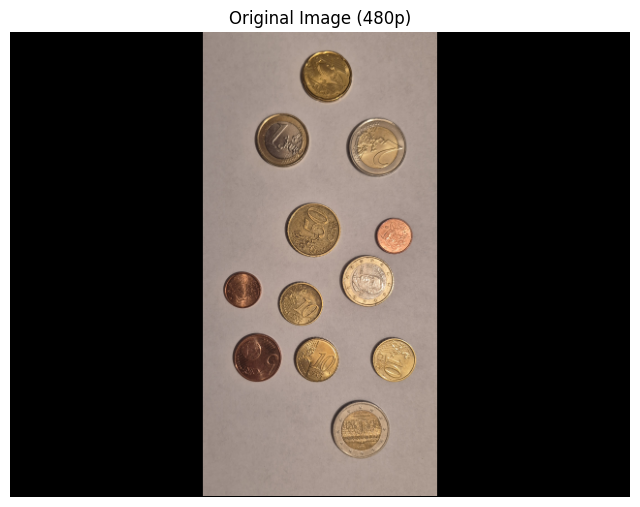

In [500]:
image_path = resolve_image_path(path)
image_bgr = read_bgr_or_raise(image_path)

image_bgr = letterbox_resize_to_canvas(image_bgr, TARGET_W, TARGET_H)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

show_image(image_rgb, "Original Image (480p)")


## 2) CLAHE (LAB) → grayscale

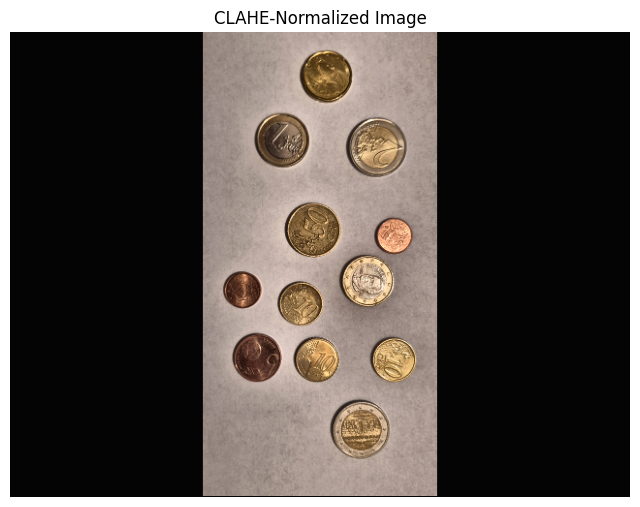

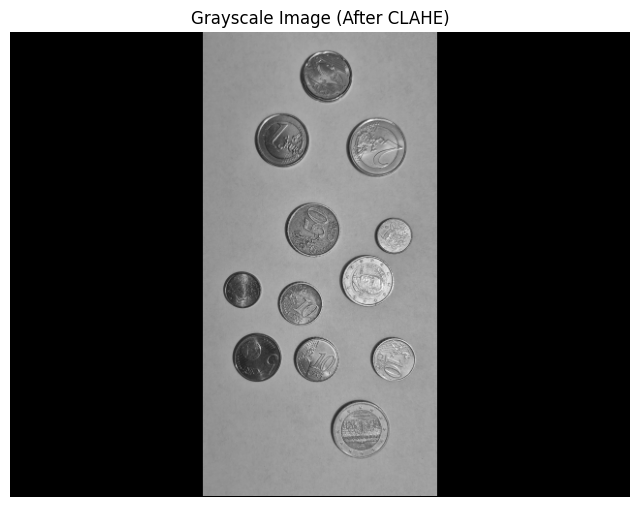

In [501]:
clahe_bgr, clahe_rgb = apply_clahe_on_l_channel(
    image_bgr,
    clip_limit=CLAHE_CLIP_LIMIT,
    tile_grid_size=CLAHE_TILE_GRID_SIZE,
)

show_image(clahe_rgb, "CLAHE-Normalized Image")

gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY) #clahe_bgr
show_image(gray, "Grayscale Image (After CLAHE)", cmap="gray")


## 3) Gaussian blur

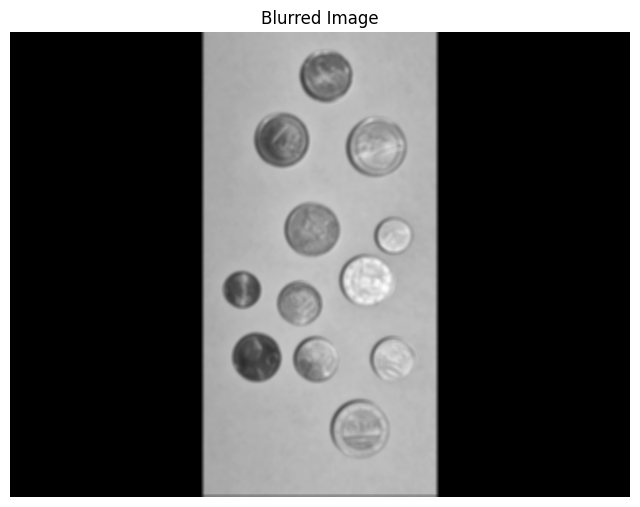

In [502]:
blurred = cv2.GaussianBlur(gray, (GAUSS_KSIZE, GAUSS_KSIZE), GAUSS_SIGMA)
show_image(blurred, "Blurred Image", cmap="gray")


## 4) Hough circles

Sweep results (minR -> n | nested | max_intrusions_in_one | intrusion_pairs | concentric_pairs):
   10 -> n= 12 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   12 -> n= 12 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   14 -> n= 12 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   16 -> n= 12 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   18 -> n= 12 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   20 -> n= 10 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   22 -> n= 10 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   24 -> n=  7 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   26 -> n=  5 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   28 -> n=  4 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   30 -> n=  2 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   32 -> n=  0 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   34 -> n=  0 | nested= 0 | max_intr= 0 | intr_pairs=  0 | conc=  0
   36 

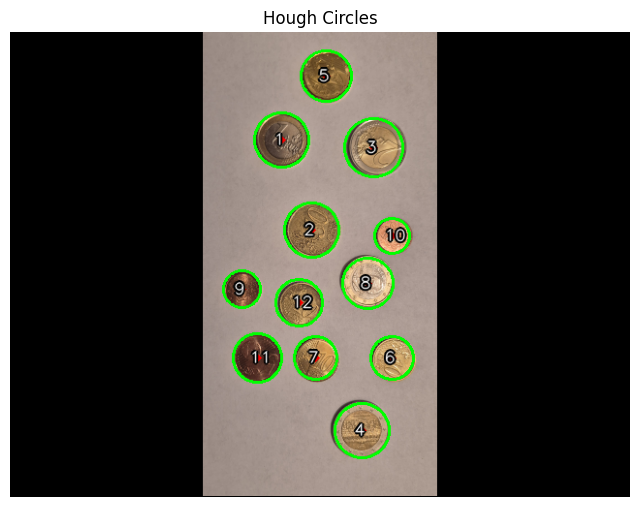

Hybrid thresholds: abs_mid=16.00, abs_hi=22.00, abs_vhi=30.00
Outlier color_delta_threshold=35.20

Average colors per coin (full / inner / border) + hybrid SAT+HUE+structure + material/euro label:
  coin#01 r=28 full=( 14, 93,107) inner=( 13, 86,104) border=( 15,113,110) sat_sim=0.894 sat_delta=27.0 hue_delta=2.0 color_delta=29.9 kmeans=0.94/1 step=0.60/1 ev=4 material=bronze(1.000) det=bi-metal-like veto=1 euro=n/a -> one-color-like [one-color-like/bronze]
  coin#02 r=28 full=( 16,125,144) inner=( 16,127,150) border=( 16,123,135) sat_sim=0.984 sat_delta=4.0 hue_delta=0.0 color_delta=6.2 kmeans=0.76/0 step=0.55/0 ev=0 material=gold(0.000) det=one-color-like veto=0 euro=n/a -> one-color-like [one-color-like/gold]
  coin#03 r=30 full=( 16, 98,165) inner=( 17,110,179) border=( 14, 77,149) sat_sim=0.871 sat_delta=33.0 hue_delta=3.0 color_delta=40.5 kmeans=0.95/1 step=0.61/1 ev=5 material=gold(0.000) det=bi-metal-like veto=0 euro=2-euro-like -> bi-metal-like [2-euro-like]
  coin#04 r=28 ful

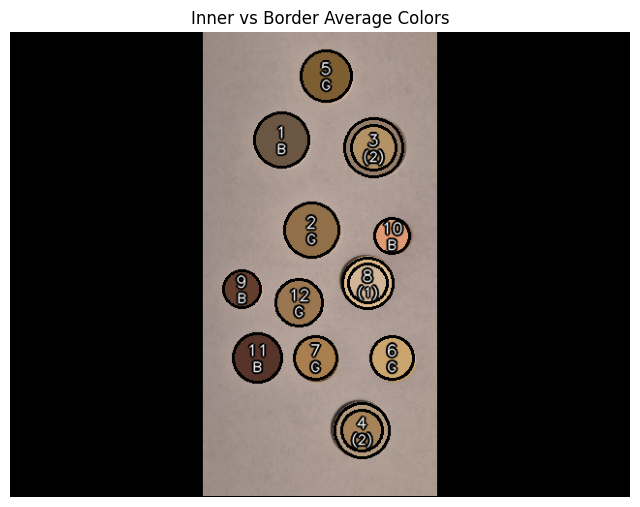

In [503]:
hough_params = HOUGH_PRESETS[ACTIVE_HOUGH_PRESET].copy()

# Dynamic param1 (NOT from preset)
param1 = auto_hough_param1_from_gradient(gray, blur_ksize=5, perc=65, scale=1.0, clamp=(30, 220)) #perc=70 
hough_params["param1"] = param1


# Dynamic min/max radius (NOT from preset)

#hough_params["minRadius"] = 5
hough_params["maxRadius"] = 100

best_minR, plate_dbg, sweep = auto_minradius_plateau(
    blurred,
    base_params=hough_params,
    minR_start=10,
    minR_end=min(140, hough_params["maxRadius"] - 1),
    step=2,
)

hough_params["minRadius"] = best_minR
print("plate_dbg:", plate_dbg)

circles = detect_hough_circles(blurred, hough_params)

output, count = draw_circles_on_rgb(image_rgb, circles)

print(f"param1(dynamic)={param1}")
if circles is not None:
    print(f"Found {count} circle(s)")
else:
    print("No circles found")

show_image(output, "Hough Circles")


#hue_fill_rgb, _ = draw_circles_filled_with_average_hue(image_bgr, circles)
#show_image(hue_fill_rgb, "Circles Filled With Average Hue")


split_rgb, split_stats = draw_and_analyze_circle_inner_border_colors(
    image_bgr,
    circles,
    border_ratio=0.24,
    sat_delta_threshold=None,
)

if circles is not None and len(split_stats) > 0:
    out_thr = split_stats[0].get("color_delta_threshold")
    abs_mid = split_stats[0].get("abs_threshold_mid")
    abs_hi = split_stats[0].get("abs_threshold_hi")
    abs_vhi = split_stats[0].get("abs_threshold_vhi")
    max_delta = max(float(row["color_delta"]) for row in split_stats)

    if abs_mid is not None and abs_hi is not None and abs_vhi is not None:
        print(f"Hybrid thresholds: abs_mid={abs_mid:.2f}, abs_hi={abs_hi:.2f}, abs_vhi={abs_vhi:.2f}")

    if out_thr is not None:
        if out_thr > max_delta:
            print(f"Outlier color_delta_threshold={out_thr:.2f} (no outlier group in this image)")
        else:
            print(f"Outlier color_delta_threshold={out_thr:.2f}")

if circles is not None:
    print("\nAverage colors per coin (full / inner / border) + hybrid SAT+HUE+structure + material/euro label:")
    for row in split_stats:
        f_h, f_s, f_v = row["full_hsv"]
        i_h, i_s, i_v = row["inner_hsv"]
        b_h, b_s, b_v = row["border_hsv"]
        print(
            f"  coin#{row['id'] + 1:02d} r={row['r']:02d} "
            f"full=({f_h:3d},{f_s:3d},{f_v:3d}) "
            f"inner=({i_h:3d},{i_s:3d},{i_v:3d}) "
            f"border=({b_h:3d},{b_s:3d},{b_v:3d}) "
            f"sat_sim={row['similarity']:.3f} "
            f"sat_delta={row['sat_delta']:.1f} "
            f"hue_delta={row['hue_delta']:.1f} "
            f"color_delta={row['color_delta']:.1f} "
            f"kmeans={row['kmeans_radial_score']:.2f}/{int(row['kmeans_radial_ok'])} "
            f"step={row['step_score']:.2f}/{int(row['step_ok'])} "
            f"ev={row['decision_evidence']} "
            f"material={row['material_label']}({row['bronze_score']:.3f}) "
            f"det={row['detector_type']} "
            f"veto={int(row['bronze_veto'])} "
            f"euro={row['bimetal_euro_label']} "
            f"-> {row['type']} [{row['label']}]"
        )

show_image(split_rgb, "Inner vs Border Average Colors")
